In [49]:
# ========================================
# 1. Configuration
# ========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from cassandra.cluster import Cluster
from cassandra.query import SimpleStatement

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D
from tensorflow.keras.layers import GlobalAveragePooling1D
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.patches as patches
import matplotlib.dates as mdates


CASSANDRA_HOST = '127.0.0.1'
CASSANDRA_PORT = 9042
KEYSPACE = 'data_stock'
SYMBOL = 'CPALL'

WINDOW_SIZE = 30
LEARNING_RATE = 0.0003
EPOCHS = 120
BATCH_SIZE = 16

In [50]:
# ========================================
# 2. Load Data from Cassandra
# ========================================
def get_data(symbol, limit=3000):
    try:
        cluster = Cluster([CASSANDRA_HOST], port=CASSANDRA_PORT)
        session = cluster.connect(KEYSPACE)

        query = """
        SELECT symbol, time, open, high, low, close, volume
        FROM candlestick_data
        WHERE symbol = %s
        LIMIT %s
        """

        statement = SimpleStatement(query)
        rows = session.execute(statement, (symbol, limit))

        df = pd.DataFrame(rows)

        cluster.shutdown()

        if df.empty:
            print("⚠ No data found")
            return None

        df['time'] = pd.to_datetime(df['time'])
        df = df.sort_values('time').reset_index(drop=True)

        print(f"✅ Loaded {len(df)} rows for {symbol}")
        return df

    except Exception as e:
        print(f"❌ Cassandra Error: {e}")
        return None


df_raw = get_data(SYMBOL)

✅ Loaded 729 rows for CPALL


In [51]:
print("Shape:", df_raw.shape)
print(df_raw.info())
print(df_raw.describe())
print("Missing values:\n", df_raw.isnull().sum())

Shape: (729, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 729 entries, 0 to 728
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   symbol  729 non-null    object        
 1   time    729 non-null    datetime64[ns]
 2   open    729 non-null    float64       
 3   high    729 non-null    float64       
 4   low     729 non-null    float64       
 5   close   729 non-null    float64       
 6   volume  729 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 40.0+ KB
None
                                time        open        high         low  \
count                            729  729.000000  729.000000  729.000000   
mean   2024-07-15 12:56:17.777777664   55.970508   56.510974   55.357682   
min              2023-01-17 00:00:00   40.750000   41.750000   40.500000   
25%              2023-10-16 00:00:00   50.250000   51.000000   49.500000   
50%              

In [52]:
# ========================================
# 3. Feature Engineering
# ========================================
def add_features(df):
    df = df.copy()

    df['ema_20'] = df['close'].ewm(span=20).mean()
    df['ema_50'] = df['close'].ewm(span=50).mean()

    df['return'] = df['close'].pct_change()
    df['volatility'] = df['return'].rolling(10).std()

    df = df.dropna()
    return df


df_feat = add_features(df_raw)

In [53]:
# ========================================
# 4. Create Labels
# ========================================
def create_labels(df):
    df = df.copy()

    df['dl_zone'] = 0  # Normal

    df.loc[
        (df['close'] > df['ema_20']) &
        (df['ema_20'] > df['ema_50']),
        'dl_zone'
    ] = 1  # Accumulation

    df.loc[
        (df['close'] < df['ema_20']) &
        (df['ema_20'] < df['ema_50']),
        'dl_zone'
    ] = 2  # Distribution

    return df


df_final = create_labels(df_feat)

print(df_final['dl_zone'].value_counts())

dl_zone
2    346
0    228
1    145
Name: count, dtype: int64


In [54]:
# ========================================
# 5. Prepare Sequences
# ========================================
features = [
    'open','high','low','close','volume',
    'ema_20','ema_50','volatility'
]

scaler = RobustScaler()
df_final[features] = scaler.fit_transform(df_final[features])


def create_sequences(df, window):
    X, y = [], []

    for i in range(window, len(df)):
        X.append(df[features].iloc[i-window:i].values)
        y.append(df['dl_zone'].iloc[i])

    return np.array(X), np.array(y)


X, y = create_sequences(df_final, WINDOW_SIZE)

print("X shape:", X.shape)

X shape: (689, 30, 8)


In [55]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [56]:
# ========================================
# 6. CNN Model
# ========================================
def create_cnn_model(input_shape, num_classes=3):
    inputs = Input(shape=input_shape)

    x = Conv1D(32, kernel_size=3, activation='relu')(inputs)
    x = MaxPooling1D(2)(x)

    x = Conv1D(64, kernel_size=3, activation='relu')(x)
    x = MaxPooling1D(2)(x)

    x = GlobalAveragePooling1D()(x)

    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


model = create_cnn_model(X_train.shape[1:])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 30, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 28, 32)         │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 14, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 12, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,363 (44.39 KB)

 Trainable params: 11,363 (44.39 KB)

 Non-trainable params: 0 (0.00 B)

In [57]:
# ========================================
# 7. Train
# ========================================
early_stop = EarlyStopping(
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/120
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4156 - loss: 1.0628 - val_accuracy: 0.5217 - val_loss: 1.0023
Epoch 2/120
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4446 - loss: 1.0167 - val_accuracy: 0.5217 - val_loss: 1.0100
Epoch 3/120
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4846 - loss: 0.9997 - val_accuracy: 0.5217 - val_loss: 1.0247
Epoch 4/120
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4864 - loss: 0.9679 - val_accuracy: 0.5217 - val_loss: 1.0584
Epoch 5/120
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5172 - loss: 0.9489 - val_accuracy: 0.5217 - val_loss: 1.0726
Epoch 6/120
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5554 - loss: 0.9307 - val_accuracy: 0.5217 - val_loss: 1.0992
Epoch 7/120
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5880 - loss: 0.8952 - val_accuracy: 0.5217 - val_loss: 1.0621
Epoch 8/120
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5935 - loss: 0.8738 - val_accuracy: 0.5217 - v

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

Classification Report:
              precision    recall  f1-score   support

      Normal     0.0000    0.0000    0.0000        43
Accumulation     0.0000    0.0000    0.0000        23
Distribution     0.5217    1.0000    0.6857        72

    accuracy                         0.5217       138
   macro avg     0.1739    0.3333    0.2286       138
weighted avg     0.2722    0.5217    0.3578       138

Weighted F1: 0.3577639751552795


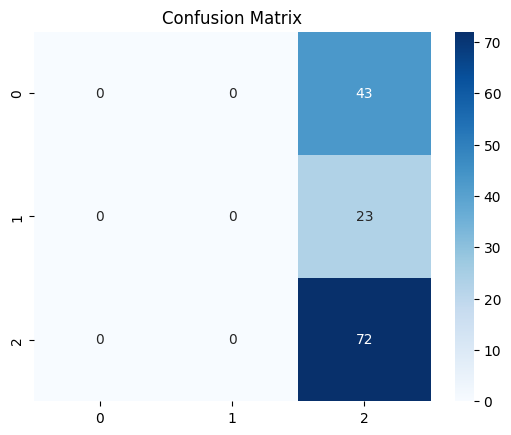

In [58]:
# ========================================
# 8. Evaluation
# ========================================
y_pred = np.argmax(model.predict(X_val), axis=1)

print("\nClassification Report:")
print(classification_report(
    y_val, y_pred,
    target_names=['Normal','Accumulation','Distribution'],
    digits=4
))

print("Weighted F1:",
      f1_score(y_val, y_pred, average='weighted'))

cm = confusion_matrix(y_val, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()